# 01. 데이터 품질 점검 및 전처리

원본 데이터의 품질을 확인하고, 파생변수 생성과 학습용 전처리 기준을 정리합니다.

> 각 Part는 설정과 입력 데이터를 다시 확인하도록 구성했습니다. 전체 실행과 부분 재실행 모두 가능합니다.

## 1. 데이터 품질 점검

### 0. 패키지와 프로젝트 상대경로 설정

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import numpy as np
import pandas as pd
import yaml

warnings.filterwarnings("ignore")


def find_project_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "config.yaml").exists():
            return candidate
    raise FileNotFoundError("config.yaml을 찾지 못했습니다. 프로젝트 폴더 안에서 실행하세요.")


ROOT = find_project_root()
with (ROOT / "config.yaml").open("r", encoding="utf-8") as file:
    cfg = yaml.safe_load(file)

DATA_DIR = ROOT / cfg["data"]["raw_dir"]
FIG_DIR = ROOT / cfg["outputs"]["figures_dir"]
METRIC_DIR = ROOT / cfg["outputs"]["metrics_dir"]
REPORT_DIR = ROOT / cfg["outputs"]["reports_dir"]

for path in [FIG_DIR, METRIC_DIR, REPORT_DIR]:
    path.mkdir(parents=True, exist_ok=True)

available_fonts = {font.name for font in fm.fontManager.ttflist}
if "Malgun Gothic" in available_fonts:
    plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)

print("PROJECT ROOT: .")
print("DATA DIR    :", DATA_DIR.relative_to(ROOT))
print("METRIC DIR  :", METRIC_DIR.relative_to(ROOT))

PROJECT ROOT: .
DATA DIR    : data\raw\home-credit-default-risk
METRIC DIR  : outputs\metrics


### 1. 데이터 로드

In [2]:
train_path = DATA_DIR / cfg["data"]["train_file"]
test_path = DATA_DIR / cfg["data"]["test_file"]

missing_files = [path for path in [train_path, test_path] if not path.exists()]
if missing_files:
    names = ", ".join(path.name for path in missing_files)
    raise FileNotFoundError(
        f"필요한 원본 파일이 없습니다: {names}. data/raw/README.md를 따라 배치하세요."
    )

app_train = pd.read_csv(train_path, low_memory=False)
app_test = pd.read_csv(test_path, low_memory=False)

print(f"application_train: {app_train.shape[0]:,}행 × {app_train.shape[1]}열")
print(f"application_test : {app_test.shape[0]:,}행 × {app_test.shape[1]}열")
print(f"train 메모리     : {app_train.memory_usage(deep=True).sum() / 1024**2:,.1f} MB")
print("\ntrain 데이터 타입:")
print(app_train.dtypes.value_counts().to_string())

application_train: 307,511행 × 122열
application_test : 48,744행 × 121열


train 메모리     : 505.0 MB

train 데이터 타입:
float64    65
int64      41
str        16


### 2. 구조적 무결성 검사

In [3]:
quality_rows = []


def record_check(check, value, passed, note):
    quality_rows.append(
        {"check": check, "value": value, "passed": bool(passed), "note": note}
    )


target_values = {int(value) for value in app_train["TARGET"].dropna().unique()}
train_only = sorted(set(app_train.columns) - set(app_test.columns))
test_only = sorted(set(app_test.columns) - set(app_train.columns))
train_duplicate_ids = int(app_train["SK_ID_CURR"].duplicated().sum())
test_duplicate_ids = int(app_test["SK_ID_CURR"].duplicated().sum())
id_overlap = int(
    len(set(app_train["SK_ID_CURR"]).intersection(set(app_test["SK_ID_CURR"])))
)
full_duplicate_rows = int(app_train.duplicated().sum())
numeric = app_train.select_dtypes(include=[np.number])
infinite_values = int(np.isinf(numeric.to_numpy()).sum())

record_check("TARGET 값 범위", sorted(target_values), target_values == {0, 1}, "0과 1만 허용")
record_check("TARGET 결측", int(app_train["TARGET"].isna().sum()), app_train["TARGET"].notna().all(), "0건이어야 함")
record_check("train 식별자 중복", train_duplicate_ids, train_duplicate_ids == 0, "SK_ID_CURR 기준")
record_check("test 식별자 중복", test_duplicate_ids, test_duplicate_ids == 0, "SK_ID_CURR 기준")
record_check("train/test 식별자 중첩", id_overlap, id_overlap == 0, "두 데이터의 신청 ID는 분리되어야 함")
record_check("train 완전 중복 행", full_duplicate_rows, full_duplicate_rows == 0, "전체 컬럼 기준")
record_check("train 전용 컬럼", train_only, train_only == ["TARGET"], "TARGET만 train에 존재해야 함")
record_check("test 전용 컬럼", test_only, len(test_only) == 0, "추가 컬럼이 없어야 함")
record_check("수치형 무한값", infinite_values, infinite_values == 0, "양·음의 무한대 합계")

quality_df = pd.DataFrame(quality_rows)
quality_df.to_csv(METRIC_DIR / "data_quality_checks.csv", index=False, encoding="utf-8-sig")
print(quality_df.to_string(index=False))

            check    value  passed                  note
      TARGET 값 범위   [0, 1]    True              0과 1만 허용
        TARGET 결측        0    True               0건이어야 함
     train 식별자 중복        0    True         SK_ID_CURR 기준
      test 식별자 중복        0    True         SK_ID_CURR 기준
train/test 식별자 중첩        0    True 두 데이터의 신청 ID는 분리되어야 함
    train 완전 중복 행        0    True              전체 컬럼 기준
      train 전용 컬럼 [TARGET]    True TARGET만 train에 존재해야 함
       test 전용 컬럼       []    True          추가 컬럼이 없어야 함
          수치형 무한값        0    True           양·음의 무한대 합계


### 3. 타깃 분포와 클래스 불균형

In [4]:
target_count = app_train["TARGET"].value_counts().sort_index()
target_ratio = app_train["TARGET"].value_counts(normalize=True).sort_index() * 100

target_df = pd.DataFrame(
    {
        "class": ["정상상환 (0)", "부도 (1)"],
        "count": [int(target_count.loc[0]), int(target_count.loc[1])],
        "ratio_percent": [target_ratio.loc[0], target_ratio.loc[1]],
    }
)
target_df["ratio_percent"] = target_df["ratio_percent"].round(2)
target_df.to_csv(METRIC_DIR / "target_distribution.csv", index=False, encoding="utf-8-sig")

imbalance_ratio = target_count.loc[0] / target_count.loc[1]
print(target_df.to_string(index=False))
print(f"\n정상:부도 = {imbalance_ratio:.2f}:1")
print("정확도만 사용하면 다수 클래스 성능에 가려질 수 있으므로 ROC-AUC, PR-AUC, Recall과 Lift를 함께 봅니다.")

   class  count  ratio_percent
정상상환 (0) 282686          91.93
  부도 (1)  24825           8.07

정상:부도 = 11.39:1
정확도만 사용하면 다수 클래스 성능에 가려질 수 있으므로 ROC-AUC, PR-AUC, Recall과 Lift를 함께 봅니다.


### 4. 결측치 점검

In [5]:
missing_count = app_train.isna().sum()
missing_rate = missing_count.div(len(app_train)).mul(100)
missing_df = (
    pd.DataFrame(
        {
            "variable": missing_count.index,
            "missing_count": missing_count.values,
            "missing_rate_percent": missing_rate.values,
        }
    )
    .query("missing_count > 0")
    .sort_values("missing_rate_percent", ascending=False)
    .reset_index(drop=True)
)
missing_df["missing_rate_percent"] = missing_df["missing_rate_percent"].round(3)
missing_df.to_csv(METRIC_DIR / "missing_rate_summary.csv", index=False, encoding="utf-8-sig")

key_notes = {
    "EXT_SOURCE_1": "외부 신용점수 1",
    "EXT_SOURCE_2": "외부 신용점수 2",
    "EXT_SOURCE_3": "외부 신용점수 3",
    "AMT_ANNUITY": "월 상환액",
    "AMT_GOODS_PRICE": "구매 상품 가격",
    "CNT_FAM_MEMBERS": "가족 구성원 수",
    "OCCUPATION_TYPE": "직업 유형",
    "DAYS_LAST_PHONE_CHANGE": "전화번호 변경 시점",
}
key_missing = missing_df[missing_df["variable"].isin(key_notes)].copy()
key_missing["note"] = key_missing["variable"].map(key_notes)
key_missing.to_csv(
    METRIC_DIR / "key_missing_summary.csv", index=False, encoding="utf-8-sig"
)

print(f"결측 변수가 있는 컬럼: {len(missing_df)}개")
print(f"결측률 50% 이상 컬럼 : {(missing_df['missing_rate_percent'] >= 50).sum()}개")
print("\n결측률 상위 15개:")
print(missing_df.head(15).to_string(index=False))

결측 변수가 있는 컬럼: 67개
결측률 50% 이상 컬럼 : 41개

결측률 상위 15개:
                variable  missing_count  missing_rate_percent
         COMMONAREA_MEDI         214865                69.872
         COMMONAREA_MODE         214865                69.872
          COMMONAREA_AVG         214865                69.872
NONLIVINGAPARTMENTS_MODE         213514                69.433
NONLIVINGAPARTMENTS_MEDI         213514                69.433
 NONLIVINGAPARTMENTS_AVG         213514                69.433
      FONDKAPREMONT_MODE         210295                68.386
    LIVINGAPARTMENTS_AVG         210199                68.355
   LIVINGAPARTMENTS_MEDI         210199                68.355
   LIVINGAPARTMENTS_MODE         210199                68.355
          FLOORSMIN_MEDI         208642                67.849
          FLOORSMIN_MODE         208642                67.849
           FLOORSMIN_AVG         208642                67.849
        YEARS_BUILD_MODE         204488                66.498
        YEARS_BUILD

### 5. 이상값과 시간 변수 점검

In [6]:
anomaly_rows = []

days_employed = app_train["DAYS_EMPLOYED"]
sentinel_count = int(days_employed.eq(365243).sum())
anomaly_rows.append(
    {
        "check": "DAYS_EMPLOYED sentinel 365243",
        "count": sentinel_count,
        "rate_percent": sentinel_count / len(app_train) * 100,
        "action": "NaN으로 바꾸고 별도 indicator 생성",
    }
)

time_columns = [
    "DAYS_BIRTH",
    "DAYS_EMPLOYED",
    "DAYS_REGISTRATION",
    "DAYS_ID_PUBLISH",
    "DAYS_LAST_PHONE_CHANGE",
]
positive_time_counts = {}
for column in time_columns:
    values = app_train[column].dropna()
    if column == "DAYS_EMPLOYED":
        values = values[values.ne(365243)]
    positive_time_counts[column] = int(values.gt(0).sum())

age_years = -app_train["DAYS_BIRTH"] / 365.25
for column in ["AMT_INCOME_TOTAL", "AMT_CREDIT", "AMT_ANNUITY", "AMT_GOODS_PRICE"]:
    non_positive = int(app_train[column].dropna().le(0).sum())
    anomaly_rows.append(
        {
            "check": f"{column} 0 이하",
            "count": non_positive,
            "rate_percent": non_positive / len(app_train) * 100,
            "action": "발견 시 원자료 정의 확인",
        }
    )

anomaly_df = pd.DataFrame(anomaly_rows)
anomaly_df["rate_percent"] = anomaly_df["rate_percent"].round(3)
anomaly_df.to_csv(METRIC_DIR / "anomaly_checks.csv", index=False, encoding="utf-8-sig")

print(f"DAYS_EMPLOYED sentinel: {sentinel_count:,}건 ({sentinel_count / len(app_train) * 100:.2f}%)")
print(f"연령 범위: {age_years.min():.1f}세 ~ {age_years.max():.1f}세")
print("\n신청일 이후를 뜻하는 양수 DAYS_* 값(sentinel 제외):")
for column, count in positive_time_counts.items():
    print(f"  {column:26s}: {count:,}건")
print("\n금액 변수 점검:")
print(anomaly_df.to_string(index=False))

DAYS_EMPLOYED sentinel: 55,374건 (18.01%)
연령 범위: 20.5세 ~ 69.1세

신청일 이후를 뜻하는 양수 DAYS_* 값(sentinel 제외):
  DAYS_BIRTH                : 0건
  DAYS_EMPLOYED             : 0건
  DAYS_REGISTRATION         : 0건
  DAYS_ID_PUBLISH           : 0건
  DAYS_LAST_PHONE_CHANGE    : 0건

금액 변수 점검:
                        check  count  rate_percent                    action
DAYS_EMPLOYED sentinel 365243  55374        18.007 NaN으로 바꾸고 별도 indicator 생성
        AMT_INCOME_TOTAL 0 이하      0         0.000            발견 시 원자료 정의 확인
              AMT_CREDIT 0 이하      0         0.000            발견 시 원자료 정의 확인
             AMT_ANNUITY 0 이하      0         0.000            발견 시 원자료 정의 확인
         AMT_GOODS_PRICE 0 이하      0         0.000            발견 시 원자료 정의 확인


### 6. 데이터 리키지 스크리닝

본 프로젝트에서 리키지는 **대출 신청 시점에는 알 수 없던 정보가 모델 입력에 들어가는 것**을 뜻합니다.
여기서는 스키마·컬럼명·시간 부호·타깃 상관을 이용해 명백한 징후를 찾습니다.

- `SK_ID_CURR`는 식별자이므로 모델 입력에서 제외합니다.
- 전처리기의 대체값과 스케일은 학습 데이터에서만 학습합니다.
- 현재 모델은 신청 테이블만 사용하며 보조 테이블의 미래 상환 이력은 결합하지 않습니다.
- 무작위 층화 분할은 시간 외 검증(out-of-time validation)이 아니라는 한계가 있습니다.

In [7]:
numeric_features = app_train.select_dtypes(include=[np.number]).columns.drop("TARGET")
absolute_target_corr = (
    app_train[numeric_features]
    .corrwith(app_train["TARGET"])
    .abs()
    .sort_values(ascending=False)
)
high_corr = absolute_target_corr[absolute_target_corr > 0.5]

suspicious_tokens = ("TARGET", "DEFAULT", "LABEL")
target_like_columns = sorted(
    column
    for column in app_train.columns
    if column != "TARGET" and any(token in column.upper() for token in suspicious_tokens)
)
positive_time_total = sum(positive_time_counts.values())

leakage_df = pd.DataFrame(
    [
        {
            "check": "train에만 존재하는 컬럼",
            "result": str(train_only),
            "passed": train_only == ["TARGET"],
            "interpretation": "TARGET 외 train 전용 컬럼 없음",
        },
        {
            "check": "타깃을 암시하는 컬럼명",
            "result": str(target_like_columns),
            "passed": len(target_like_columns) == 0,
            "interpretation": "TARGET/DEFAULT/LABEL 명칭 스크리닝",
        },
        {
            "check": "TARGET과 절대상관 0.5 초과",
            "result": str(high_corr.index.tolist()),
            "passed": len(high_corr) == 0,
            "interpretation": "강한 단변량 누수 징후 스크리닝",
        },
        {
            "check": "양수 DAYS_* 값",
            "result": positive_time_total,
            "passed": positive_time_total == 0,
            "interpretation": "신청 이후 시점 징후; sentinel 제외",
        },
        {
            "check": "식별자 모델 입력 제외 정책",
            "result": "SK_ID_CURR",
            "passed": True,
            "interpretation": "후속 피처 노트북에서 제외",
        },
        {
            "check": "보조 상환 테이블 결합 여부",
            "result": "미결합",
            "passed": True,
            "interpretation": "현재 입력은 application_train만 사용",
        },
    ]
)
leakage_df.to_csv(
    METRIC_DIR / "leakage_screening.csv", index=False, encoding="utf-8-sig"
)

print(leakage_df.to_string(index=False))
if len(high_corr):
    print("\n상관 0.5 초과 변수:")
    print(high_corr.to_string())
else:
    print("\nTARGET과 절대상관 0.5를 초과하는 수치형 입력 변수는 없습니다.")

              check     result  passed               interpretation
    train에만 존재하는 컬럼 ['TARGET']    True      TARGET 외 train 전용 컬럼 없음
       타깃을 암시하는 컬럼명         []    True TARGET/DEFAULT/LABEL 명칭 스크리닝
TARGET과 절대상관 0.5 초과         []    True            강한 단변량 누수 징후 스크리닝
        양수 DAYS_* 값          0    True     신청 이후 시점 징후; sentinel 제외
    식별자 모델 입력 제외 정책 SK_ID_CURR    True               후속 피처 노트북에서 제외
    보조 상환 테이블 결합 여부        미결합    True 현재 입력은 application_train만 사용

TARGET과 절대상관 0.5를 초과하는 수치형 입력 변수는 없습니다.


### 7. 변수 그룹 카탈로그

In [8]:
groups = {
    "식별·종속": ["SK_ID_CURR", "TARGET"],
    "인적사항": ["CODE_GENDER", "DAYS_BIRTH", "CNT_CHILDREN", "CNT_FAM_MEMBERS", "NAME_FAMILY_STATUS"],
    "재무": ["AMT_INCOME_TOTAL", "AMT_CREDIT", "AMT_ANNUITY", "AMT_GOODS_PRICE"],
    "고용·교육": ["NAME_INCOME_TYPE", "NAME_EDUCATION_TYPE", "OCCUPATION_TYPE", "ORGANIZATION_TYPE", "DAYS_EMPLOYED"],
    "외부신용점수": ["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"],
    "신용조회이력": [column for column in app_train if column.startswith("AMT_REQ_CREDIT")],
    "문서제출플래그": [column for column in app_train if column.startswith("FLAG_DOCUMENT")],
    "건물정보": [column for column in app_train if column.endswith(("_AVG", "_MODE", "_MEDI"))],
}

group_df = pd.DataFrame(
    [
        {"group": group, "column_count": len([column for column in columns if column in app_train])}
        for group, columns in groups.items()
    ]
)
print(group_df.to_string(index=False))

  group  column_count
  식별·종속             2
   인적사항             5
     재무             4
  고용·교육             5
 외부신용점수             3
 신용조회이력             6
문서제출플래그            20
   건물정보            47


### 8. 진단 그림과 보고서 저장

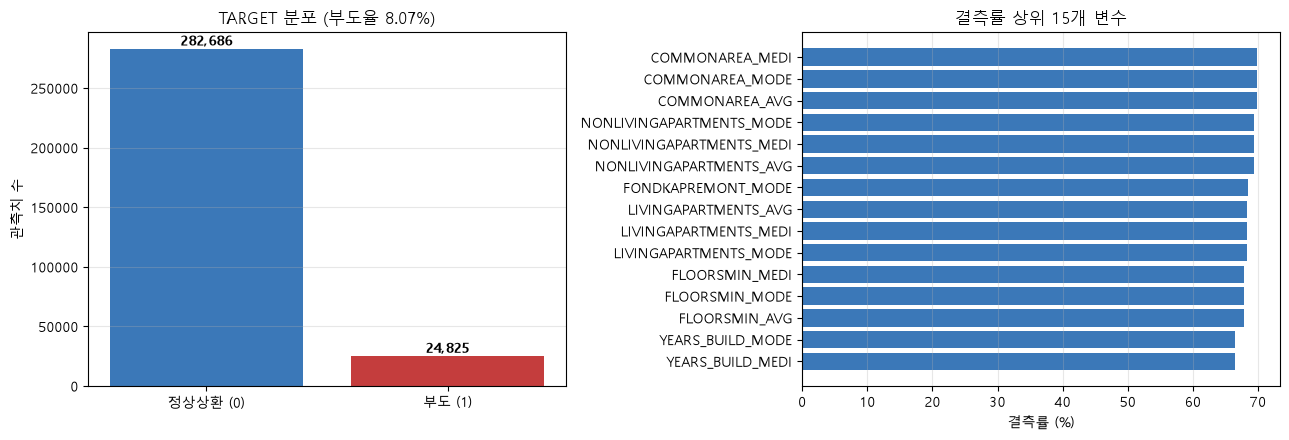

저장: outputs\figures\target_distribution_missing_rates.png
저장: outputs\reports\data_audit_summary.md

Phase 2 데이터 품질·리키지 점검 완료


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

colors = ["#3b78b8", "#c43d3d"]
axes[0].bar(["정상상환 (0)", "부도 (1)"], target_count.values, color=colors)
axes[0].set_title(f"TARGET 분포 (부도율 {target_ratio.loc[1]:.2f}%)")
axes[0].set_ylabel("관측치 수")
for index, value in enumerate(target_count.values):
    axes[0].text(index, value + len(app_train) * 0.01, f"{value:,}", ha="center", fontweight="bold")
axes[0].grid(axis="y", alpha=0.3)

top15 = missing_df.head(15).iloc[::-1]
axes[1].barh(top15["variable"], top15["missing_rate_percent"], color="#3b78b8")
axes[1].set_title("결측률 상위 15개 변수")
axes[1].set_xlabel("결측률 (%)")
axes[1].grid(axis="x", alpha=0.3)

fig.tight_layout()
figure_path = FIG_DIR / "target_distribution_missing_rates.png"
fig.savefig(figure_path, dpi=150, bbox_inches="tight")
plt.show()

quality_passed = int(quality_df["passed"].sum())
leakage_passed = int(leakage_df["passed"].sum())
report = f'''# Data Audit Summary

## 실행 결과

- 학습 데이터: {app_train.shape[0]:,}행 × {app_train.shape[1]}열
- 평가 데이터: {app_test.shape[0]:,}행 × {app_test.shape[1]}열
- 부도율: {target_ratio.loc[1]:.2f}%
- 구조적 품질 검사 통과: {quality_passed}/{len(quality_df)}
- 리키지 스크리닝 통과: {leakage_passed}/{len(leakage_df)}
- DAYS_EMPLOYED sentinel: {sentinel_count:,}건

## 판단

스키마, 식별자, 타깃 범위, 시간 변수 부호와 단변량 상관에서 명백한 직접 누수 징후는 발견되지 않았습니다.
다만 이 결과만으로 누수 부재가 증명되는 것은 아닙니다. 후속 노트북에서는 SK_ID_CURR를 제외하고,
데이터 분할 후 학습 데이터에만 전처리기를 적합해야 합니다.

## 한계

현재 모델은 application_train만 사용합니다. 무작위 층화 검증은 시간 외 성능을 검증하지 않으며,
보조 테이블을 추후 결합할 경우 각 레코드의 관측 시점을 별도로 확인해야 합니다.
'''
report = "\n".join(line.strip() for line in report.strip().splitlines()) + "\n"
(REPORT_DIR / "data_audit_summary.md").write_text(report, encoding="utf-8")

print("저장:", figure_path.relative_to(ROOT))
print("저장:", (REPORT_DIR / "data_audit_summary.md").relative_to(ROOT))
print("\nPhase 2 데이터 품질·리키지 점검 완료")

## 2. 파생변수 생성 및 전처리

### 0. 패키지와 프로젝트 상대경로 설정

In [10]:
from pathlib import Path
import warnings

import joblib
import numpy as np
import pandas as pd
import yaml
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings("ignore")


def find_project_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "config.yaml").exists():
            return candidate
    raise FileNotFoundError("config.yaml을 찾지 못했습니다. 프로젝트 폴더 안에서 실행하세요.")


ROOT = find_project_root()
with (ROOT / "config.yaml").open("r", encoding="utf-8") as file:
    cfg = yaml.safe_load(file)

DATA_DIR = ROOT / cfg["data"]["raw_dir"]
METRIC_DIR = ROOT / cfg["outputs"]["metrics_dir"]
MODEL_DIR = ROOT / cfg["outputs"]["models_dir"]
REPORT_DIR = ROOT / cfg["outputs"]["reports_dir"]
for path in [METRIC_DIR, MODEL_DIR, REPORT_DIR]:
    path.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = int(cfg["modeling"]["random_state"])
VALID_SIZE = float(cfg["modeling"]["valid_size"])

print("PROJECT ROOT: .")
print("DATA DIR    :", DATA_DIR.relative_to(ROOT))
print("RANDOM STATE:", RANDOM_STATE)
print("VALID SIZE  :", VALID_SIZE)

PROJECT ROOT: .
DATA DIR    : data\raw\home-credit-default-risk
RANDOM STATE: 42
VALID SIZE  : 0.2


### 1. 데이터 로드와 sentinel 처리

In [11]:
train_path = DATA_DIR / cfg["data"]["train_file"]
if not train_path.exists():
    raise FileNotFoundError("application_train.csv가 없습니다. data/raw/README.md를 확인하세요.")

df = pd.read_csv(train_path, low_memory=False)
required_columns = {
    "SK_ID_CURR", "TARGET", "DAYS_EMPLOYED", "DAYS_BIRTH",
    "AMT_CREDIT", "AMT_INCOME_TOTAL", "AMT_ANNUITY",
    "EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3",
}
missing_required = sorted(required_columns - set(df.columns))
if missing_required:
    raise KeyError(f"필수 컬럼이 없습니다: {missing_required}")

sentinel_mask = df["DAYS_EMPLOYED"].eq(365243)
df["DAYS_EMPLOYED_ANOM"] = sentinel_mask.astype("int8")
df.loc[sentinel_mask, "DAYS_EMPLOYED"] = np.nan

print(f"원본 데이터: {df.shape[0]:,}행 × {df.shape[1] - 1}개 원본 컬럼")
print(f"DAYS_EMPLOYED sentinel → NaN: {sentinel_mask.sum():,}건")
print(f"전체 부도율: {df['TARGET'].mean() * 100:.3f}%")

원본 데이터: 307,511행 × 122개 원본 컬럼
DAYS_EMPLOYED sentinel → NaN: 55,374건
전체 부도율: 8.073%


### 2. 행 단위 파생변수 13개 생성

In [12]:
def safe_divide(numerator: pd.Series, denominator: pd.Series) -> pd.Series:
    # 0인 분모를 결측값으로 바꾼 뒤 안전하게 나눕니다.
    return numerator.div(denominator.replace(0, np.nan))


df["CREDIT_INCOME_RATIO"] = safe_divide(df["AMT_CREDIT"], df["AMT_INCOME_TOTAL"])
df["ANNUITY_INCOME_RATIO"] = safe_divide(df["AMT_ANNUITY"], df["AMT_INCOME_TOTAL"])
df["CREDIT_TERM"] = safe_divide(df["AMT_CREDIT"], df["AMT_ANNUITY"])
df["DAYS_EMPLOYED_PERCENT"] = safe_divide(df["DAYS_EMPLOYED"], df["DAYS_BIRTH"])

ext_columns = ["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]
df["EXT_SOURCE_MEAN"] = df[ext_columns].mean(axis=1)
df["EXT_SOURCE_MIN"] = df[ext_columns].min(axis=1)
df["EXT_SOURCE_MAX"] = df[ext_columns].max(axis=1)
df["EXT_SOURCE_STD"] = df[ext_columns].std(axis=1)
for column in ext_columns:
    df[f"{column}_NA"] = df[column].isna().astype("int8")
df["EXT_NOT_NA_COUNT"] = df[ext_columns].notna().sum(axis=1).astype("int8")

derived_features = [
    "CREDIT_INCOME_RATIO", "ANNUITY_INCOME_RATIO", "CREDIT_TERM",
    "DAYS_EMPLOYED_PERCENT", "EXT_SOURCE_MEAN", "EXT_SOURCE_MIN",
    "EXT_SOURCE_MAX", "EXT_SOURCE_STD", "EXT_SOURCE_1_NA",
    "EXT_SOURCE_2_NA", "EXT_SOURCE_3_NA", "EXT_NOT_NA_COUNT",
    "DAYS_EMPLOYED_ANOM",
]
df.replace([np.inf, -np.inf], np.nan, inplace=True)

feature_catalog = pd.DataFrame(
    [
        ("CREDIT_INCOME_RATIO", "AMT_CREDIT / AMT_INCOME_TOTAL", "재무 비율"),
        ("ANNUITY_INCOME_RATIO", "AMT_ANNUITY / AMT_INCOME_TOTAL", "재무 비율"),
        ("CREDIT_TERM", "AMT_CREDIT / AMT_ANNUITY", "재무 비율"),
        ("DAYS_EMPLOYED_PERCENT", "DAYS_EMPLOYED / DAYS_BIRTH", "고용 비율"),
        ("EXT_SOURCE_MEAN", "EXT_SOURCE 3종 평균", "외부 점수 통계"),
        ("EXT_SOURCE_MIN", "EXT_SOURCE 3종 최솟값", "외부 점수 통계"),
        ("EXT_SOURCE_MAX", "EXT_SOURCE 3종 최댓값", "외부 점수 통계"),
        ("EXT_SOURCE_STD", "EXT_SOURCE 3종 표준편차", "외부 점수 통계"),
        ("EXT_SOURCE_1_NA", "EXT_SOURCE_1 결측 여부", "결측 indicator"),
        ("EXT_SOURCE_2_NA", "EXT_SOURCE_2 결측 여부", "결측 indicator"),
        ("EXT_SOURCE_3_NA", "EXT_SOURCE_3 결측 여부", "결측 indicator"),
        ("EXT_NOT_NA_COUNT", "EXT_SOURCE 비결측 개수", "결측 indicator"),
        ("DAYS_EMPLOYED_ANOM", "DAYS_EMPLOYED sentinel 여부", "이상값 indicator"),
    ],
    columns=["feature", "definition", "group"],
)
feature_catalog.to_csv(
    METRIC_DIR / "feature_engineering_catalog.csv",
    index=False,
    encoding="utf-8-sig",
)

print(f"파생변수 {len(derived_features)}개 생성")
print(feature_catalog.to_string(index=False))
print("파생변수 내 무한값:", int(np.isinf(df[derived_features].to_numpy()).sum()))

파생변수 13개 생성
              feature                     definition         group
  CREDIT_INCOME_RATIO  AMT_CREDIT / AMT_INCOME_TOTAL         재무 비율
 ANNUITY_INCOME_RATIO AMT_ANNUITY / AMT_INCOME_TOTAL         재무 비율
          CREDIT_TERM       AMT_CREDIT / AMT_ANNUITY         재무 비율
DAYS_EMPLOYED_PERCENT     DAYS_EMPLOYED / DAYS_BIRTH         고용 비율
      EXT_SOURCE_MEAN               EXT_SOURCE 3종 평균      외부 점수 통계
       EXT_SOURCE_MIN              EXT_SOURCE 3종 최솟값      외부 점수 통계
       EXT_SOURCE_MAX              EXT_SOURCE 3종 최댓값      외부 점수 통계
       EXT_SOURCE_STD             EXT_SOURCE 3종 표준편차      외부 점수 통계
      EXT_SOURCE_1_NA             EXT_SOURCE_1 결측 여부  결측 indicator
      EXT_SOURCE_2_NA             EXT_SOURCE_2 결측 여부  결측 indicator
      EXT_SOURCE_3_NA             EXT_SOURCE_3 결측 여부  결측 indicator
     EXT_NOT_NA_COUNT              EXT_SOURCE 비결측 개수  결측 indicator
   DAYS_EMPLOYED_ANOM      DAYS_EMPLOYED sentinel 여부 이상값 indicator
파생변수 내 무한값: 0


### 3. 식별자·타깃 제외 후 층화 분할

In [13]:
X = df.drop(columns=["SK_ID_CURR", "TARGET"])
y = df["TARGET"].astype("int8")

assert "SK_ID_CURR" not in X.columns
assert "TARGET" not in X.columns

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=VALID_SIZE,
    stratify=y,
    random_state=RANDOM_STATE,
)

index_overlap = len(set(X_train.index).intersection(set(X_valid.index)))
assert index_overlap == 0
assert len(X_train) + len(X_valid) == len(X)

split_summary = pd.DataFrame(
    [
        ("전체", len(y), int(y.sum()), y.mean() * 100),
        ("학습", len(y_train), int(y_train.sum()), y_train.mean() * 100),
        ("검증", len(y_valid), int(y_valid.sum()), y_valid.mean() * 100),
    ],
    columns=["split", "n", "default_count", "default_rate_percent"],
)
split_summary["default_rate_percent"] = split_summary["default_rate_percent"].round(3)
split_summary.to_csv(
    METRIC_DIR / "train_validation_split_summary.csv", index=False, encoding="utf-8-sig"
)

print(split_summary.to_string(index=False))
print(f"학습/검증 인덱스 중첩: {index_overlap}건")
print(f"모델 입력 변수: {X.shape[1]}개")

split      n  default_count  default_rate_percent
   전체 307511          24825                 8.073
   학습 246008          19860                 8.073
   검증  61503           4965                 8.073
학습/검증 인덱스 중첩: 0건
모델 입력 변수: 133개


### 4. 클래스 불균형 대응 원칙

부도 관측치를 복제하거나 정상 관측치를 삭제하지 않습니다. 원래 데이터와 부도율을 보존한 상태에서 모델 학습 시 클래스 가중치를 적용합니다.

- Logistic Regression·LinearSVC·RBF SVM: `class_weight='balanced'`
- LDA: 두 클래스의 사전확률을 동일하게 설정
- 평가지표: ROC-AUC뿐 아니라 PR-AUC, Recall, Precision, F1, Lift를 함께 사용

RBF SVM의 5만 행 층화 표본은 계산량을 줄이기 위한 것이며 불균형 보정용 언더샘플링으로 해석하지 않습니다.

In [14]:
classes = np.array([0, 1], dtype="int8")
balanced_weights = compute_class_weight(
    class_weight="balanced", classes=classes, y=y_train
)
class_weight_map = {
    int(label): float(weight) for label, weight in zip(classes, balanced_weights)
}

imbalance_strategy = pd.DataFrame(
    [
        {
            "item": "학습 데이터 부도율",
            "value": f"{y_train.mean() * 100:.3f}%",
            "reason": "층화 분할로 원래 분포 보존",
        },
        {
            "item": "정상 클래스 가중치",
            "value": f"{class_weight_map[0]:.4f}",
            "reason": "sklearn balanced 공식",
        },
        {
            "item": "부도 클래스 가중치",
            "value": f"{class_weight_map[1]:.4f}",
            "reason": "소수 클래스 오분류 영향 확대",
        },
        {
            "item": "리샘플링",
            "value": "사용하지 않음",
            "reason": "원자료 분포와 모든 관측치 보존",
        },
    ]
)
imbalance_strategy.to_csv(
    METRIC_DIR / "class_imbalance_strategy.csv", index=False, encoding="utf-8-sig"
)
print(imbalance_strategy.to_string(index=False))

      item   value              reason
학습 데이터 부도율  8.073%     층화 분할로 원래 분포 보존
정상 클래스 가중치  0.5439 sklearn balanced 공식
부도 클래스 가중치  6.1936    소수 클래스 오분류 영향 확대
      리샘플링 사용하지 않음   원자료 분포와 모든 관측치 보존


### 5. 학습 데이터에만 전처리기 적합

In [15]:
numeric_columns = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_columns = X_train.select_dtypes(include=["object", "category"]).columns.tolist()

numeric_pipeline = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)
categorical_pipeline = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
        (
            "encoder",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
        ),
    ]
)
preprocessor = ColumnTransformer(
    [
        ("num", numeric_pipeline, numeric_columns),
        ("cat", categorical_pipeline, categorical_columns),
    ]
)

# 핵심 누수 방지: fit은 학습 데이터에서 단 한 번만 수행합니다.
preprocessor.fit(X_train)
X_train_prepared = preprocessor.transform(X_train).astype("float32")
X_valid_prepared = preprocessor.transform(X_valid).astype("float32")

raw_feature_names = preprocessor.get_feature_names_out().tolist()
feature_names = [
    name.removeprefix("num__").removeprefix("cat__") for name in raw_feature_names
]
transformed_feature_std = X_train_prepared.std(axis=0).astype("float32")

train_missing = int(np.isnan(X_train_prepared).sum())
valid_missing = int(np.isnan(X_valid_prepared).sum())
assert train_missing == 0 and valid_missing == 0

preprocessing_summary = pd.DataFrame(
    [
        ("fit 대상", "학습 데이터만", "검증 데이터 통계 사용 방지"),
        ("수치형", f"{len(numeric_columns)}개", "중앙값 대체 후 표준화"),
        ("범주형", f"{len(categorical_columns)}개", "Unknown 대체 후 One-Hot"),
        ("변환 후", f"{len(feature_names)}개", "수치형 + 더미 변수"),
        ("학습 결측", train_missing, "0이어야 함"),
        ("검증 결측", valid_missing, "0이어야 함"),
    ],
    columns=["item", "value", "note"],
)
preprocessing_summary.to_csv(
    METRIC_DIR / "preprocessing_summary.csv",
    index=False,
    encoding="utf-8-sig",
)

print(preprocessing_summary.to_string(index=False))
print("학습 배열:", X_train_prepared.shape, X_train_prepared.dtype)
print("검증 배열:", X_valid_prepared.shape, X_valid_prepared.dtype)

  item   value                 note
fit 대상 학습 데이터만      검증 데이터 통계 사용 방지
   수치형    117개         중앙값 대체 후 표준화
   범주형     16개 Unknown 대체 후 One-Hot
  변환 후    263개          수치형 + 더미 변수
 학습 결측       0               0이어야 함
 검증 결측       0               0이어야 함
학습 배열: (246008, 263) float32
검증 배열: (61503, 263) float32


### 6. 학습 데이터에서만 파생변수 단변량 점검

In [16]:
train_for_check = df.loc[X_train.index, derived_features + ["TARGET"]]
derived_correlations = (
    train_for_check.corr(numeric_only=True)["TARGET"]
    .drop("TARGET")
    .sort_values(key=lambda values: values.abs(), ascending=False)
    .rename("target_correlation")
    .reset_index(name="target_correlation")
    .rename(columns={"index": "feature"})
)
derived_correlations.to_csv(
    METRIC_DIR / "derived_feature_correlations.csv",
    index=False,
    encoding="utf-8-sig",
)

print(derived_correlations.round(4).to_string(index=False))
print("\n주의: 상관은 단변량 연관성일 뿐 인과효과나 모델 중요도를 뜻하지 않습니다.")

              feature  target_correlation
      EXT_SOURCE_MEAN             -0.2219
       EXT_SOURCE_MAX             -0.1970
       EXT_SOURCE_MIN             -0.1852
DAYS_EMPLOYED_PERCENT             -0.0678
       EXT_SOURCE_STD              0.0471
   DAYS_EMPLOYED_ANOM             -0.0464
          CREDIT_TERM             -0.0332
     EXT_NOT_NA_COUNT             -0.0279
      EXT_SOURCE_3_NA              0.0220
      EXT_SOURCE_1_NA              0.0188
 ANNUITY_INCOME_RATIO              0.0155
  CREDIT_INCOME_RATIO             -0.0074
      EXT_SOURCE_2_NA             -0.0006

주의: 상관은 단변량 연관성일 뿐 인과효과나 모델 중요도를 뜻하지 않습니다.


### 7. 모델링용 번들과 검증 보고서 저장

In [17]:
bundle = {
    "X_train": X_train_prepared,
    "X_valid": X_valid_prepared,
    "y_train": y_train.to_numpy(dtype="int8"),
    "y_valid": y_valid.to_numpy(dtype="int8"),
    "feature_names": feature_names,
    "transformed_feature_std": transformed_feature_std,
    "preprocessor": preprocessor,
    "numeric_columns": numeric_columns,
    "categorical_columns": categorical_columns,
    "derived_features": derived_features,
    "class_weight_map": class_weight_map,
    "meta": {
        "random_state": RANDOM_STATE,
        "valid_size": VALID_SIZE,
        "n_raw_features": X.shape[1],
        "n_transformed_features": len(feature_names),
        "baseline_default_rate": float(y.mean()),
        "preprocessor_fit_scope": "train_only",
        "resampling": "none",
    },
}
bundle_path = MODEL_DIR / "phase3_bundle.pkl"
joblib.dump(bundle, bundle_path, compress=3)

report = f'''# Feature Engineering and Imbalance Summary

## 분할

- 학습 데이터: {len(y_train):,}건, 부도율 {y_train.mean() * 100:.3f}%
- 검증 데이터: {len(y_valid):,}건, 부도율 {y_valid.mean() * 100:.3f}%
- 학습/검증 인덱스 중첩: 0건
- random_state: {RANDOM_STATE}

## 전처리

- 모델 입력에서 SK_ID_CURR와 TARGET 제외
- 파생변수: {len(derived_features)}개
- 전처리기 적합 범위: 학습 데이터만
- 변환 후 피처: {len(feature_names)}개
- 변환 후 결측값: 학습 {train_missing}개, 검증 {valid_missing}개

## 클래스 불균형

리샘플링은 사용하지 않고 원래 관측치를 보존했습니다. 다음 모델링 단계에서 balanced 클래스 가중치를 적용합니다.
계산된 학습 가중치는 정상 {class_weight_map[0]:.4f}, 부도 {class_weight_map[1]:.4f}입니다.

## 해석상 주의

수치형 변수는 표준화되지만 One-Hot 더미는 0/1 값입니다. 따라서 두 종류의 로지스틱 계수를 절댓값으로 직접 비교하지 않습니다.
다음 단계에서는 학습 데이터의 변환 후 표준편차를 이용한 표준화 효과와 permutation importance를 별도로 제시합니다.
'''
report = "\n".join(line.strip() for line in report.strip().splitlines()) + "\n"
(REPORT_DIR / "feature_engineering_summary.md").write_text(report, encoding="utf-8")

print("저장:", bundle_path.relative_to(ROOT))
print(f"번들 크기: {bundle_path.stat().st_size / 1024**2:.1f} MB (Git 제외)")
print("저장:", (REPORT_DIR / "feature_engineering_summary.md").relative_to(ROOT))

저장: outputs\models\phase3_bundle.pkl
번들 크기: 58.2 MB (Git 제외)
저장: outputs\reports\feature_engineering_summary.md


### 8. Phase 3 요약

In [18]:
print(f"파생변수: {len(derived_features)}개")
print(f"학습 데이터: {X_train_prepared.shape[0]:,}행 × {X_train_prepared.shape[1]}열")
print(f"검증 데이터: {X_valid_prepared.shape[0]:,}행 × {X_valid_prepared.shape[1]}열")
print(f"학습/검증 부도율: {y_train.mean() * 100:.3f}% / {y_valid.mean() * 100:.3f}%")
print("전처리 fit 범위: 학습 데이터만")
print("리샘플링: 사용하지 않음")
print("Phase 3 완료")

파생변수: 13개
학습 데이터: 246,008행 × 263열
검증 데이터: 61,503행 × 263열
학습/검증 부도율: 8.073% / 8.073%
전처리 fit 범위: 학습 데이터만
리샘플링: 사용하지 않음
Phase 3 완료
